# Cyanobacteria prediction for Lake Neuchâtel (transposed model)

There's no open in-lake data for Lake Neuchâtel (water temperature, stratification, etc.), so I can't train directly on it. Instead I train a model on weather variables that are available anywhere through Open-Meteo, using Lake Greifensee (a comparable peri-alpine lake), and then apply it to Neuchâtel.

In [15]:
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

## 1. Getting the weather data

This function pulls daily weather (temperature, wind, precipitation, radiation, sunshine) for one location over a date range, in a single Open-Meteo request.

In [16]:
def fetch_weather_range(lat, lon, start, end):
    """Use Open-Meteo to get temperature for a certain location."""
    params = {
        "latitude": lat, "longitude": lon,
        "start_date": start, "end_date": end,
        "daily": "temperature_2m_mean,wind_speed_10m_max,precipitation_sum,"
                 "shortwave_radiation_sum,sunshine_duration",
        "timezone": "auto",
    }
    r = requests.get("https://archive-api.open-meteo.com/v1/archive", params=params, timeout=60)
    r.raise_for_status()
    wx = pd.DataFrame(r.json()["daily"])
    wx["date"] = pd.to_datetime(wx["time"])
    return wx.drop(columns="time")

## 2. Building the training set

I match the Greifensee bloom target from `dataset.csv` with its Open-Meteo weather, and add the month encoded as sine and cosine.

In [17]:
GREIFEN = (47.366, 8.677) # Greifensee coordinates

df = pd.read_csv("../data/processed/dataset.csv", parse_dates=["date"]).sort_values("date")
wx_g = fetch_weather_range(*GREIFEN, df["date"].min().date().isoformat(), df["date"].max().date().isoformat())

train = df[["date", "target"]].merge(wx_g, on="date", how="inner")
train["month_sin"] = np.sin(2*np.pi*train["date"].dt.month/12)
train["month_cos"] = np.cos(2*np.pi*train["date"].dt.month/12)

## 3. Training the model
Logistic Regression to see the trend of the model.

Random Forest, evaluated with 5-fold stratified cross-validation, using only the weather and season features.

In [18]:
FEATURES = ["temperature_2m_mean", "wind_speed_10m_max", "precipitation_sum",
              "shortwave_radiation_sum", "sunshine_duration", "month_sin", "month_cos"]

X, y = train[FEATURES], train["target"]

### 3.1 Logistic Regression
Logistic regression values ​​need to be scaled because their range of values ​​varies considerably.

In [19]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [26]:
auc_lr = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
print("Logistic Regression ROC-AUC :", auc_lr.mean().round(3), "±", auc_lr.std().round(3))

Logistic Regression ROC-AUC : 0.651 ± 0.082


ROC-AUC is 0.65. Since 0.5 means the model has no predictive capacities, it is still an honest result but not the best neither.

### 3.2 Random Forest

In [27]:
clf = RandomForestClassifier(class_weight="balanced", random_state=42)

auc_rf = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")
ap_rf = cross_val_score(clf, X, y, cv=cv, scoring="average_precision")
print("Random Forest ROC-AUC :", auc_rf.mean().round(3), "±", auc_rf.std().round(3))
print("Random Forest PR-AUC :", ap_rf.mean().round(3), "±", ap_rf.std().round(3))

Random Forest ROC-AUC : 0.819 ± 0.035
Random Forest PR-AUC : 0.576 ± 0.07


ROC-AUC is 0.82 (0.5 would be random), so the model separates blooms from non-blooms pretty well. PR-AUC is 0.58, well above the 0.25 base rate. This result is way better than the Logistic Regression one, so it will be kept as the main model.

The full in-lake model in the other notebook got 0.90, so I don't lose much by keeping only the transposable weather features, which is what makes applying it to Neuchâtel reasonable.

In [22]:
NEUCHATEL = (46.92, 6.86)   # Neuchatel lake coordinates

wx_n = fetch_weather_range(*NEUCHATEL, "2019-01-01", "2023-12-31")
wx_n["month_sin"] = np.sin(2*np.pi*wx_n["date"].dt.month/12)
wx_n["month_cos"] = np.cos(2*np.pi*wx_n["date"].dt.month/12)

clf.fit(X, y)

df["proba_pred"] = cross_val_predict(clf, X, y, cv=cv, method="predict_proba")[:, 1]
imp = pd.Series(clf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(imp)

temperature_2m_mean        0.216795
shortwave_radiation_sum    0.159652
sunshine_duration          0.153950
month_sin                  0.130531
wind_speed_10m_max         0.128846
month_cos                  0.124326
precipitation_sum          0.085900
dtype: float64


Temperature is the most used variable, then radiation and sunshine. The importances are fairly spread out, so the model isn't just reading off the calendar month, it really uses the weather conditions.

## 4. Daily probability for Lake Neuchâtel

Blooms predicted probability, day by day, smoothed over 14 days, to check the seasonal pattern.

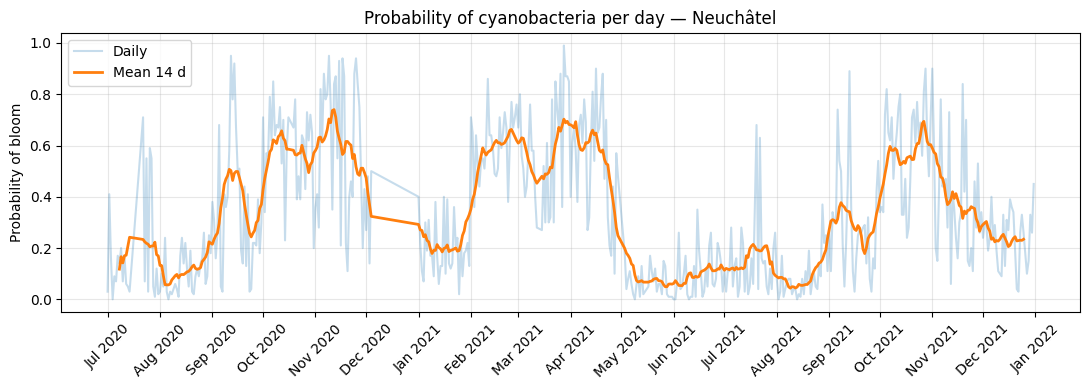

In [23]:
df = df.sort_values("date")

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(df["date"], df["proba_pred"], alpha=0.25, label="Daily")
ax.plot(df["date"], df["proba_pred"].rolling(14, center=True).mean(),
        lw=2, label="Mean 14 d")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)

ax.set_ylabel("Probability of bloom")
ax.set_title("Probability of cyanobacteria per day — Neuchâtel")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/cyano_per_day_neuchatel.svg")
plt.show()

## 5. Applying the model to Neuchâtel

I run the trained model on five years of Neuchâtel weather (2019-2023) and average the probability by month.

This is an extrapolation by analogy: the model was never validated on real Neuchâtel data. And because of `class_weight="balanced"`, the absolute probabilities are inflated, so what matters here is the shape of the curve, not the exact values.

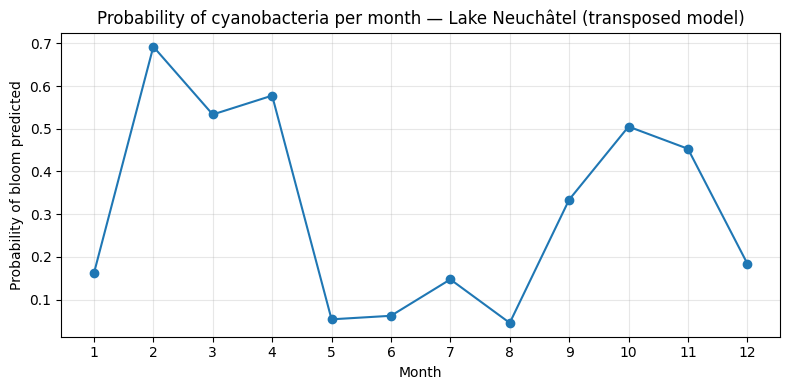

In [24]:
wx_n["proba"] = clf.predict_proba(wx_n[FEATURES])[:, 1]
proba_mois = wx_n.groupby(wx_n["date"].dt.month)["proba"].mean()

plt.figure(figsize=(8, 4))
plt.plot(proba_mois.index, proba_mois.values, marker="o")
plt.xticks(range(1, 13))
plt.xlabel("Month"); plt.ylabel("Probability of bloom predicted")
plt.title("Probability of cyanobacteria per month — Lake Neuchâtel (transposed model)")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("../reports/figures/neuchatel_proba_monthly.svg")
plt.show()

The probability peaks in the cold season and drops in summer. This fits the ecology of Planktothrix in deep peri-alpine lakes like Neuchâtel: winter mixing brings the cyanobacteria from the deeper layers up toward the surface, while summer stratification keeps them down.

## 6. Looking at the errors

The model catches about 61% of the blooms (recall) with a precision of 0.55, weaker than the full in-lake model. That's the trade-off for keeping it transposable.

In [25]:
pred = cross_val_predict(clf, X, y, cv=cv)
print(confusion_matrix(y, pred))
print(classification_report(y, pred))

[[314  65]
 [ 49  78]]
              precision    recall  f1-score   support

           0       0.87      0.83      0.85       379
           1       0.55      0.61      0.58       127

    accuracy                           0.77       506
   macro avg       0.71      0.72      0.71       506
weighted avg       0.78      0.77      0.78       506

